# Chapter 13. Processing Sequences Using RNNs and CNNs

Recurrent neural networks (RNNs) are designed for sequential data such as time series, text, audio, and trajectories.

Unlike feedforward networks, RNNs can process sequences of varying lengths and use information from previous time steps when computing the current output.

## Recurrent Neurons and Layers

A recurrent neuron receives both:

- The current input $x_{(t)}$
- Its output from the previous time step $\hat{y}_{(t-1)}$

The previous output is fed back into the neuron, allowing information to persist across time.

Representing the same recurrent neuron repeatedly across time steps is called **unrolling the network through time**.

At the first time step, there is no previous output, so it is usually initialized to zero.

Each recurrent neuron has two sets of weights:

- $W_x$ for the current input
- $W_{\hat{y}}$ for the previous output

For a recurrent layer, the current output is computed from both the current input and the previous output:

$$
\hat{Y}^{(t)}
=
\phi
\left(
X_{(t)}W_x
+
\hat{Y}_{(t-1)}W_{\hat{y}}
+
b
\right)
$$

Here, $\phi$ is the activation function, such as `ReLU`, applied to the weighted sum.

For a mini-batch:

- $X_{(t)}$ contains the current inputs for all instances.
- $\hat{Y}_{(t-1)}$ contains the previous outputs.
- $W_x$ maps the current inputs to the recurrent neurons.
- $W_{\hat{y}}$ maps the previous outputs back to the recurrent neurons.

Because $\hat{Y}_{(t)}$ depends on $\hat{Y}_{(t-1)}$, which depends on earlier outputs, the current output indirectly depends on all previous inputs in the sequence.

This recurrent feedback gives the network a form of memory.

### Memory Cells

A memory cell is a part of an RNN that preserves information across time steps.

Its hidden state at time step $t$, denoted $h_{(t)}$, depends on both the current input and the previous hidden state:

$$
h_{(t)} = f\left(x_{(t)}, h_{(t-1)}\right)
$$

The output $\hat{y}_{(t)}$ also depends on the current input and previous state, and is typically a function of the current hidden state.

For a basic RNN cell, the output is equal to the hidden state.

More complex cells may keep the hidden state and output separate.

### Input and Output Sequences

RNNs can have different input-output structures:

- **Sequence-to-sequence:** A sequence in, a sequence out.
- **Sequence-to-vector:** A sequence in, one final output.
- **Vector-to-sequence:** One input vector generates a sequence.
- **Encoder-decoder:** An encoder converts an input sequence into a vector, and a decoder generates an output sequence from it.

## Training RNNs

RNNs are trained using **backpropagation through time (BPTT)**.

The network is first unrolled across time steps, followed by a forward pass to compute the outputs and loss. The loss may use all outputs or only selected ones depending on the task.

During backpropagation, gradients flow backward through the unrolled network.

Because the same weights and biases are reused at every time step, their gradients receive contributions from multiple time steps before the parameters are updated with gradient descent.

## Forecasting a Time Series

A time series contains values observed over time, usually at regular intervals.

- **Univariate time series:** one value per time step
- **Multivariate time series:** multiple values per time step

Here, daily bus and rail ridership form a multivariate time series.

In [28]:
import pandas as pd
from pathlib import Path

path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total
df = df.drop_duplicates() # remove duplicated months
df["bus"] = pd.to_numeric(df["bus"].str.replace(",", "", regex=False))
df["rail"] = pd.to_numeric(df["rail"].str.replace(",", "", regex=False))

In [30]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


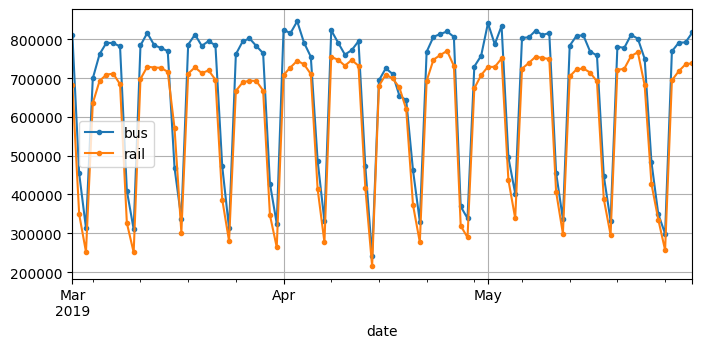

In [32]:
import matplotlib.pyplot as plt

df.loc["2019-03":"2019-05", ["bus", "rail"]].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

The ridership data shows strong weekly seasonality, meaning a similar pattern repeats every seven days.

A simple baseline is **naive forecasting**, which predicts a future value by copying a past observation. Because of the strong weekly pattern, using the value from seven days earlier works well here.

A time series is **autocorrelated** when it is correlated with a lagged version of itself.

Here, a 7-day lag provides a simple forecast, while differencing measures the error between the current value and the value from one week earlier.

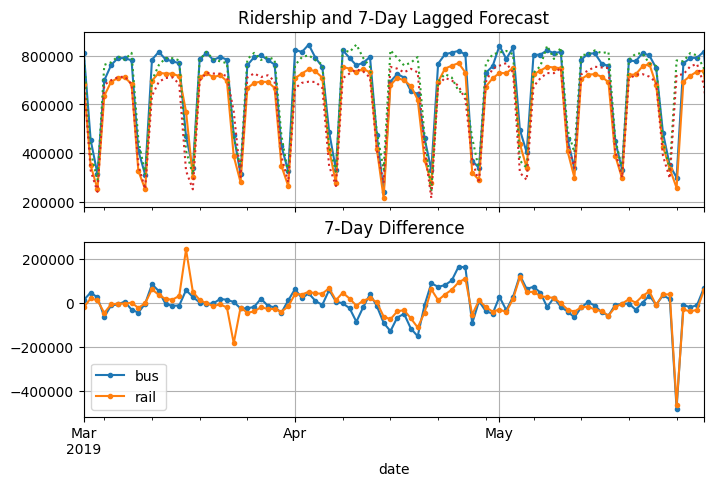

In [65]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":") # lagged
axs[0].set_title("Ridership and 7-Day Lagged Forecast")
axs[0].set_ylim(180000, 900000)
diff_7.plot(ax=axs[1], grid=True, marker=".") # 7-day difference time series
axs[1].set_title("7-Day Difference")
plt.show()

In [44]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [46]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Common forecasting metrics include:

- **MAE:** average absolute forecast error
- **MAPE:** average absolute error relative to the target value
- **MSE:** penalizes larger errors more strongly by squaring them

The ridership data also contains longer-term trends and yearly seasonality.

A rolling average helps visualize long-term patterns, while **differencing** can remove trend and seasonality to make the series more stationary.

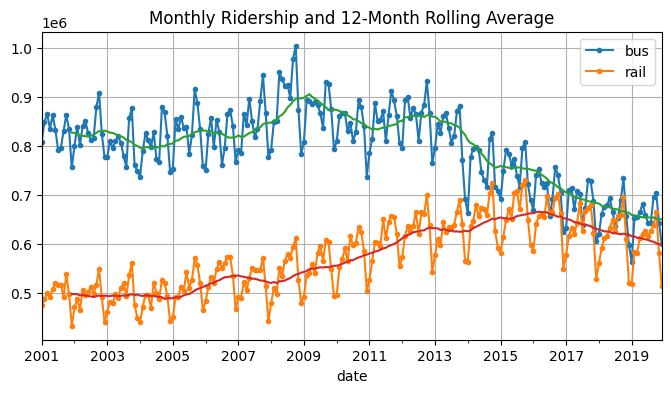

In [67]:
period = slice("2001", "2019")
df_monthly = df[["bus", "rail"]].resample("ME").mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
ax.set_title("Monthly Ridership and 12-Month Rolling Average")
plt.show()

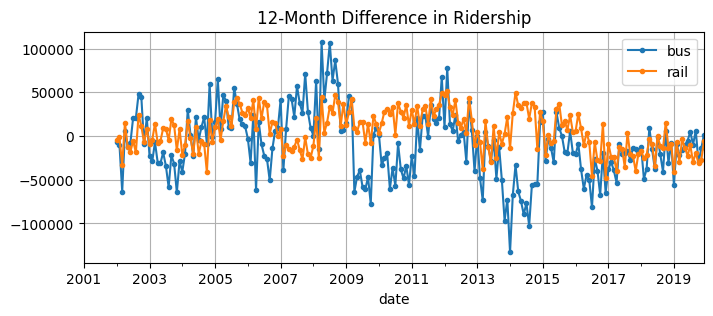

In [69]:
ax = df_monthly.diff(12).loc[period].plot(grid=True, marker=".", figsize=(8, 3))
ax.set_title("12-Month Difference in Ridership")
plt.show()

A **stationary time series** has statistical properties that remain relatively stable over time, without strong trends or seasonality.

Differencing is commonly used to make a time series more stationary and therefore easier to model.